In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("cell_eval_results.csv")
df_gold = pd.read_parquet("../../data/cell/cell_papers_all_novelty_scores.parquet")


df.columns = ['PaperProjectID', 'openalex', 'TrustScore']
df["openalex"] = df["openalex"].apply(lambda x: x[len("https://openalex.org/"):])

In [2]:
df.columns, df_gold.columns

(Index(['PaperProjectID', 'openalex', 'TrustScore'], dtype='str'),
 Index(['pubmed_id', 'openalex', 'novelty_sum', 'top5_novel', 'top10_novel',
        'wangs_novelty', 'dindex', 'forward_citations_openalex', 'new_finding',
        'originality'],
       dtype='str'))

In [3]:
df_gold.info()

<class 'pandas.DataFrame'>
RangeIndex: 6770 entries, 0 to 6769
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pubmed_id                   6770 non-null   str    
 1   openalex                    6616 non-null   str    
 2   novelty_sum                 6770 non-null   float64
 3   top5_novel                  6770 non-null   bool   
 4   top10_novel                 6770 non-null   bool   
 5   wangs_novelty               4106 non-null   float64
 6   dindex                      6482 non-null   float64
 7   forward_citations_openalex  6616 non-null   float64
 8   new_finding                 6770 non-null   float64
 9   originality                 6770 non-null   float64
dtypes: bool(2), float64(6), str(2)
memory usage: 561.3 KB


In [4]:
all_df = df.merge(df_gold, on='openalex', how='left')
all_df

,PaperProjectID,openalex,TrustScore,pubmed_id,novelty_sum,top5_novel,top10_novel,wangs_novelty,dindex,forward_citations_openalex,new_finding,originality
0,0,W1965843055,0.083793,11779465,1.0,False,False,NaN,-0.009080,711.0,1.0,0.855799
1,2,W2150589615,0.075911,11779461,8.0,True,True,NaN,-0.010714,820.0,7.0,0.890620
2,3,W2087575288,0.089192,11779460,1.0,False,False,NaN,-0.007171,305.0,1.0,0.902148
3,4,W1989011389,0.089492,11779462,0.0,False,False,NaN,-0.051230,1142.0,0.0,0.816867
4,5,W2133097845,0.107611,11779466,3.0,False,False,NaN,-0.000970,453.0,2.0,0.816114
...,...,...,...,...,...,...,...,...,...,...,...,...
5714,6756,W3120564033,0.148866,33417860,0.0,False,False,9.820886,-0.000289,398.0,0.0,0.925108
5715,6757,W3116063736,0.108990,33378642,2.0,False,False,1.128606,-0.001029,240.0,1.0,0.875495
5716,6758,W3111998353,0.107433,33333019,1.0,False,False,14.029419,-0.000673,505.0,1.0,0.905170
5717,6759,W3118420218,0.128970,33417862,5.0,False,True,7.184158,-0.000404,67.0,2.0,0.718611


In [5]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5719 entries, 0 to 5718
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PaperProjectID              5719 non-null   int64  
 1   openalex                    5719 non-null   str    
 2   TrustScore                  5719 non-null   float64
 3   pubmed_id                   5719 non-null   str    
 4   novelty_sum                 5719 non-null   float64
 5   top5_novel                  5719 non-null   bool   
 6   top10_novel                 5719 non-null   bool   
 7   wangs_novelty               3442 non-null   float64
 8   dindex                      5608 non-null   float64
 9   forward_citations_openalex  5719 non-null   float64
 10  new_finding                 5719 non-null   float64
 11  originality                 5719 non-null   float64
dtypes: bool(2), float64(7), int64(1), str(2)
memory usage: 564.9 KB


In [6]:
all_df = all_df[df['TrustScore'] != -1]

In [7]:
score_columns = [col for col in all_df.columns if col not in ['PaperProjectID', 'openalex', 'pubmed_id']]


corr = all_df[score_columns].corr(numeric_only=True, method='spearman')


In [8]:
corr

,TrustScore,novelty_sum,top5_novel,top10_novel,wangs_novelty,dindex,forward_citations_openalex,new_finding,originality
TrustScore,1.000000,-0.037514,0.003030,0.000688,0.093677,0.127857,-0.091858,-0.039961,0.098780
novelty_sum,-0.037514,1.000000,0.394719,0.534995,0.083039,-0.056064,0.266626,0.939675,0.003273
top5_novel,0.003030,0.394719,1.000000,0.696486,0.053493,-0.002399,0.159188,0.385599,0.004151
top10_novel,0.000688,0.534995,0.696486,1.000000,0.063928,0.019703,0.156714,0.501840,0.030491
wangs_novelty,0.093677,0.083039,0.053493,0.063928,1.000000,0.190511,0.111162,0.077007,0.536455
dindex,0.127857,-0.056064,-0.002399,0.019703,0.190511,1.000000,-0.272654,-0.082917,0.292215
forward_citations_openalex,-0.091858,0.266626,0.159188,0.156714,0.111162,-0.272654,1.000000,0.266802,0.022609
new_finding,-0.039961,0.939675,0.385599,0.501840,0.077007,-0.082917,0.266802,1.000000,-0.019881
originality,0.098780,0.003273,0.004151,0.030491,0.536455,0.292215,0.022609,-0.019881,1.000000


In [9]:
corr = all_df[['TrustScore', 'novelty_sum', 'top5_novel', 'wangs_novelty', 'dindex']].corr()

In [10]:
corr

,TrustScore,novelty_sum,top5_novel,wangs_novelty,dindex
TrustScore,1.000000,-0.016173,0.008115,0.082192,0.098920
novelty_sum,-0.016173,1.000000,0.705398,0.086610,0.008037
top5_novel,0.008115,0.705398,1.000000,0.059246,0.024325
wangs_novelty,0.082192,0.086610,0.059246,1.000000,0.094034
dindex,0.098920,0.008037,0.024325,0.094034,1.000000


In [11]:
all_df['TrustScore'].min()

np.float64(0.0393342971801757)

In [12]:
all_df["top10_ours"] = (all_df["TrustScore"] > all_df['TrustScore'].quantile(0.90))
all_df["top10_novel"] = all_df["top10_novel"].astype(bool)

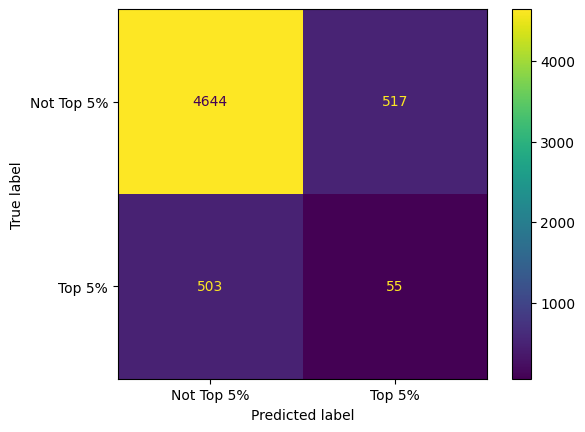

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_df['top10_novel'], all_df['top10_ours'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Top 5%', 'Top 5%'])
disp.plot()

In [14]:
all_df['top5_novel'].info()

<class 'pandas.Series'>
RangeIndex: 5719 entries, 0 to 5718
Series name: top5_novel
Non-Null Count  Dtype
--------------  -----
5719 non-null   bool 
dtypes: bool(1)
memory usage: 5.7 KB


In [15]:
all_df['top5_ours'].info()

KeyError: 'top5_ours'

In [ ]:
all_df["TrustScore"].describe()

count    5910.000000
mean        0.110965
std         0.030108
min         0.039435
25%         0.089124
50%         0.106132
75%         0.127823
max         0.232406
Name: TrustScore, dtype: float64